In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


X, y = load_iris(return_X_y=True)


model = RandomForestClassifier()

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'criterion': ['gini', 'entropy'],
    'min_samples_split':[2,3,4]
    
}


grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)


grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)


print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best Score: 0.9666666666666668


In [3]:
optmizedmodel=RandomForestClassifier(criterion='gini',max_depth=5,n_estimators=50)

In [5]:
optmizedmodel

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint   # FIXED

X, y = load_iris(return_X_y=True)

model = RandomForestClassifier()

param_grid = {
    'n_estimators': randint(50,200),
    'max_depth': randint(1,15),
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    verbose=1
)

random_search.fit(X, y)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 6, 'n_estimators': 106}
Best Score: 0.9666666666666668


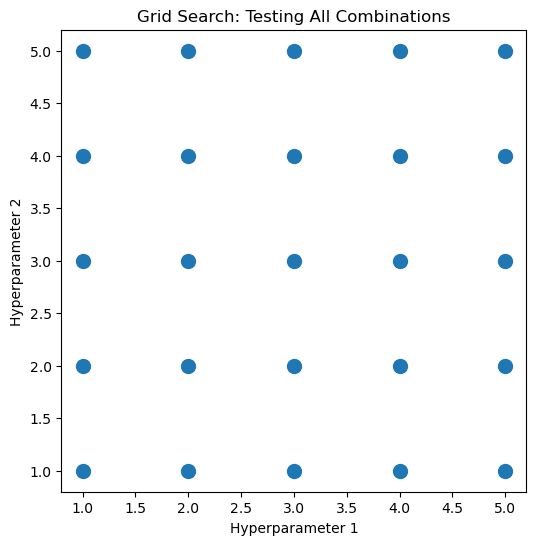

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns

import numpy as np

param1 = np.linspace(1, 5, 5)
param2 = np.linspace(1, 5, 5)


grid_x, grid_y = np.meshgrid(param1, param2)

plt.figure(figsize=(6,6))
plt.scatter(grid_x, grid_y, s=100)

plt.title("Grid Search: Testing All Combinations")
plt.xlabel("Hyperparameter 1")
plt.ylabel("Hyperparameter 2")

plt.show()

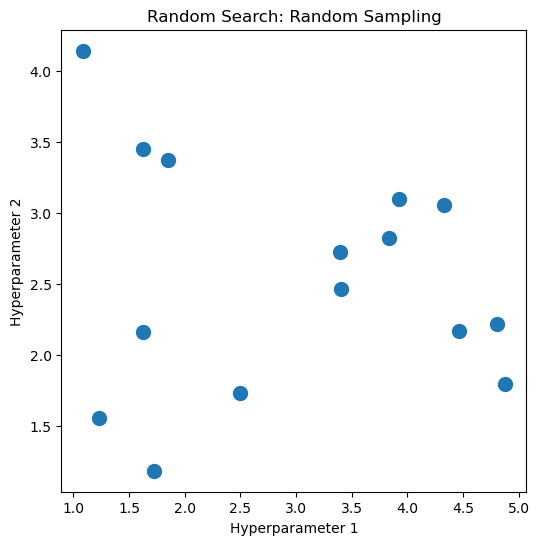

In [20]:
np.random.seed(42)


random_x = np.random.uniform(1,5,15)
random_y = np.random.uniform(1,5,15)

plt.figure(figsize=(6,6))
plt.scatter(random_x, random_y, s=100)

plt.title("Random Search: Random Sampling")
plt.xlabel("Hyperparameter 1")
plt.ylabel("Hyperparameter 2")

plt.show()

# Transfer Learning

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

In [23]:

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


In [25]:
# normalize the imeage
train_images = train_images / 255.0
test_images = test_images / 255.0


# reshaping the image according to mobilev2net
train_images = tf.image.resize(train_images, (224,224))
test_images = tf.image.resize(test_images, (224,224))


ResourceExhaustedError: {{function_node __wrapped__ResizeBilinear_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[50000,224,224,3] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:ResizeBilinear] name: 

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Load CIFAR10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0

# Convert to dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

# Resize function
def preprocess(image, label):
    image = tf.image.resize(image, (224,224))
    return image, label

# Apply preprocessing
train_dataset = train_dataset.map(preprocess).batch(32)
test_dataset = test_dataset.map(preprocess).batch(32)

# Load pretrained model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# base_model = MobileNetV2(
#     input_shape=(224,224,3),
#     include_top=False,
#     weights='imagenet'
# )


# base_model.trainable = False

# model = models.Sequential([
    
#     base_model,
    
#     layers.GlobalAveragePooling2D(),
    
#     layers.Dense(128, activation='relu'),
    
#     layers.Dense(10, activation='softmax')
# ])

# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )


In [ ]:

model.fit(train_dataset, epochs=5, validation_data=test_dataset)

In [ ]:

# history = model.fit(
#     train_images,
#     train_labels,
#     epochs=5,
#     validation_data=(test_images, test_labels)
# )


# test_loss, test_acc = model.evaluate(test_images, test_labels)

# print("Test Accuracy:", test_acc)